## Import Libraries and GPU Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# GPU setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Speed optimization
torch.backends.cudnn.benchmark = True

Using device: cpu


## Device Setup

## Load and Sort Dataset

In [3]:
df = pd.read_csv("../data/indoorAir2.csv")

# Convert timestamp once
df["timestamp"] = pd.to_datetime(df["timestamp"], unit="s")

# Sort efficiently
df = df.sort_values("timestamp").reset_index(drop=True)

print(df.shape)
df.head()

(1924653, 21)


,id,station_id,station_name,timestamp,scd41_co2,scd41_temperature,scd41_humidity,ens160_eco2,ens160_tvoc,ens160_aqi,...,svm41_humidity,svm41_nox_index,svm41_voc_index,bme688_temperature,bme688_humidity,bme688_pressure,bme688_gas_resistance,sfa30_temperature,sfa30_humidity,sfa30_hco
0,1,1,station_room_233,2024-11-13 16:57:56,488.0,22.951857,36.897277,418,32,1,...,34.060001,29.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,1,station_room_233,2024-11-13 16:58:57,485.0,22.335011,38.185119,414,30,1,...,34.209999,79.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,1,station_room_233,2024-11-13 16:59:59,477.0,22.353704,38.400268,443,43,1,...,34.180000,99.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,1,station_room_233,2024-11-13 17:01:03,474.0,22.417792,38.269042,406,26,1,...,34.130001,93.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,1,station_room_233,2024-11-13 17:02:05,473.0,22.556649,37.971496,416,31,1,...,34.240001,98.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Cyclic Time Feature Engineering

In [9]:

# Extract time information only once
hour = (
    df["timestamp"].dt.hour +
    df["timestamp"].dt.minute / 60
)

dayofweek = df["timestamp"].dt.dayofweek

# Hour cyclic encoding
df["hour_sin"] = np.sin(
    2 * np.pi * hour / 24
)
df["hour_cos"] = np.cos(
    2 * np.pi * hour / 24
)

# Day of week cyclic encoding
df["dayofweek_sin"] = np.sin(
    2 * np.pi * dayofweek / 7
)
df["dayofweek_cos"] = np.cos(
    2 * np.pi * dayofweek / 7
)

# Weekend feature
df["is_weekend"] = (
    dayofweek.isin([5, 6]).astype(int)
)

# Final feature dataframe
feature_df = df[
    [
        "ens160_aqi",
        "ens160_tvoc",
        "bme688_gas_resistance",
        "bme688_pressure",
        "scd41_temperature",
        "scd41_humidity",
        "timestamp",
        "scd41_co2",
        "hour_sin",
        "hour_cos",
        "dayofweek_sin",
        "dayofweek_cos",
        "is_weekend",
        "station_id",
    ]
].copy()

print("Feature Data Shape:", feature_df.shape)
feature_df.head()

Feature Data Shape: (1924653, 14)


,ens160_aqi,ens160_tvoc,bme688_gas_resistance,bme688_pressure,scd41_temperature,scd41_humidity,timestamp,scd41_co2,hour_sin,hour_cos,dayofweek_sin,dayofweek_cos,is_weekend,station_id
0,1,32,NaN,NaN,22.951857,36.897277,2024-11-13 16:57:56,488.0,-0.962455,-0.271440,0.974928,-0.222521,0,1
1,1,30,NaN,NaN,22.335011,38.185119,2024-11-13 16:58:57,485.0,-0.963630,-0.267238,0.974928,-0.222521,0,1
2,1,43,NaN,NaN,22.353704,38.400268,2024-11-13 16:59:59,477.0,-0.964787,-0.263031,0.974928,-0.222521,0,1
3,1,26,NaN,NaN,22.417792,38.269042,2024-11-13 17:01:03,474.0,-0.967046,-0.254602,0.974928,-0.222521,0,1
4,1,31,NaN,NaN,22.556649,37.971496,2024-11-13 17:02:05,473.0,-0.968148,-0.250380,0.974928,-0.222521,0,1


## Train Validation Test Split

In [10]:
# Define station groups
train_stations = [1, 2, 4, 6]
val_stations = [3]
test_stations = [5]

# Create train validation and test datasets
train_df = feature_df[feature_df["station_id"].isin(train_stations)].copy()
val_df = feature_df[feature_df["station_id"].isin(val_stations)].copy()
test_df = feature_df[feature_df["station_id"].isin(test_stations)].copy()

# Print dataset shapes
print("Train Shape      :", train_df.shape)
print("Validation Shape :", val_df.shape)
print("Test Shape       :", test_df.shape)

# Verify station distribution
print("\nTrain Stations:", train_df["station_id"].unique())
print("Validation Stations:", val_df["station_id"].unique())
print("Test Stations:", test_df["station_id"].unique())

Train Shape      : (1310556, 14)
Validation Shape : (361836, 14)
Test Shape       : (252261, 14)

Train Stations: [1 2 4 6]
Validation Stations: [3]
Test Stations: [5]


## Remove Large Timestamp Gaps

In [7]:
def remove_large_gaps(data, threshold_hours=3):
    data = data.copy()

    # Ensure timestamp is datetime index
    if "timestamp" in data.columns:
        data["timestamp"] = pd.to_datetime(data["timestamp"])
        data = data.sort_values("timestamp").set_index("timestamp")
    else:
        data.index = pd.to_datetime(data.index)
        data = data.sort_index()

    # Calculate time differences
    time_diff = data.index.to_series().diff()
    gap_threshold = pd.Timedelta(hours=threshold_hours)

    # Identify large gaps
    large_gaps = time_diff > gap_threshold
    print("Large gaps found:",large_gaps.sum())

    # Remove rows after large gaps
    cleaned_data = data.loc[~large_gaps]
    return cleaned_data


# Apply gap removal
train_df = remove_large_gaps(train_df)
val_df = remove_large_gaps(val_df)
test_df = remove_large_gaps(test_df)

# Print final shapes
print("\nAfter Removing Large Gaps")
print("Train Shape      :", train_df.shape)
print("Validation Shape :", val_df.shape)
print("Test Shape       :", test_df.shape)

NameError: name 'train_df' is not defined

## Resample Each Station Separately

In [6]:
def resample_station_data(data, freq="15min"):

    station_data_list = []
    # Process each station separately
    for station in data["station_id"].unique():
        # Select one station
        station_df = data[
            data["station_id"] == station
        ].copy()
        # Sort by timestamp index
        station_df = station_df.sort_index()
        # Resample
        station_df = station_df.resample(freq).mean()
        # Restore station ID
        station_df["station_id"] = station
        # Store result
        station_data_list.append(station_df)

    # Combine all stations
    final_df = pd.concat(station_data_list)
    return final_df

# Apply resampling
train_df = resample_station_data(train_df)
val_df = resample_station_data(val_df)
test_df = resample_station_data(test_df)

# Print shapes after resampling
print("After Resampling\n")
print("Train Shape      :", train_df.shape)
print("Validation Shape :", val_df.shape)
print("Test Shape       :", test_df.shape)

After Resampling

Train Shape      : (113528, 13)
Validation Shape : (44163, 13)
Test Shape       : (29203, 13)


## Handle Missing Values

In [7]:
def handle_missing_values(data):
    # Time-based interpolation
    data = data.interpolate(method="time")
    
    # Forward fill remaining missing values
    data = data.ffill()
    
    # Backward fill remaining missing values
    data = data.bfill()
    
    # Drop any remaining NaN values
    data = data.dropna()
    return data
    
# Apply missing value handling
train_df = handle_missing_values(train_df)
val_df = handle_missing_values(val_df)
test_df = handle_missing_values(test_df)

# Check missing values
print("Train Missing Values      :", train_df.isna().sum().sum())
print("Validation Missing Values :", val_df.isna().sum().sum())
print("Test Missing Values       :", test_df.isna().sum().sum())

# Final dataset shapes
print("\nAfter Missing Value Handling\n")
print("Train Shape      :", train_df.shape)
print("Validation Shape :", val_df.shape)
print("Test Shape       :", test_df.shape)

Train Missing Values      : 0
Validation Missing Values : 0
Test Missing Values       : 0

After Missing Value Handling

Train Shape      : (113528, 13)
Validation Shape : (44163, 13)
Test Shape       : (29203, 13)


## Feature Scaling and Normalization

In [22]:
feature_columns = [

    "ens160_aqi",
    "ens160_tvoc",
    "bme688_gas_resistance",
    "bme688_pressure",
    "scd41_temperature",
    "scd41_humidity",
    "scd41_co2",

    "hour_sin",
    "hour_cos",

    "dayofweek_sin",
    "dayofweek_cos",

    "is_weekend"
]

# Keep only existing columns
feature_columns = [
    col for col in feature_columns
    if col in train_df.columns
]

# Select features
train_features = train_df[feature_columns]
val_features = val_df[feature_columns]
test_features = test_df[feature_columns]

# Initialize scaler
scaler = MinMaxScaler()

# Fit only on training data
train_scaled = scaler.fit_transform(train_features)
val_scaled = scaler.transform(val_features)
test_scaled = scaler.transform(test_features)

# Print scaled data shapes
print("Train Scaled Shape      :", train_scaled.shape)
print("Validation Scaled Shape :", val_scaled.shape)
print("Test Scaled Shape       :", test_scaled.shape)

NameError: name 'train_df' is not defined

## Visualize Normalization Results

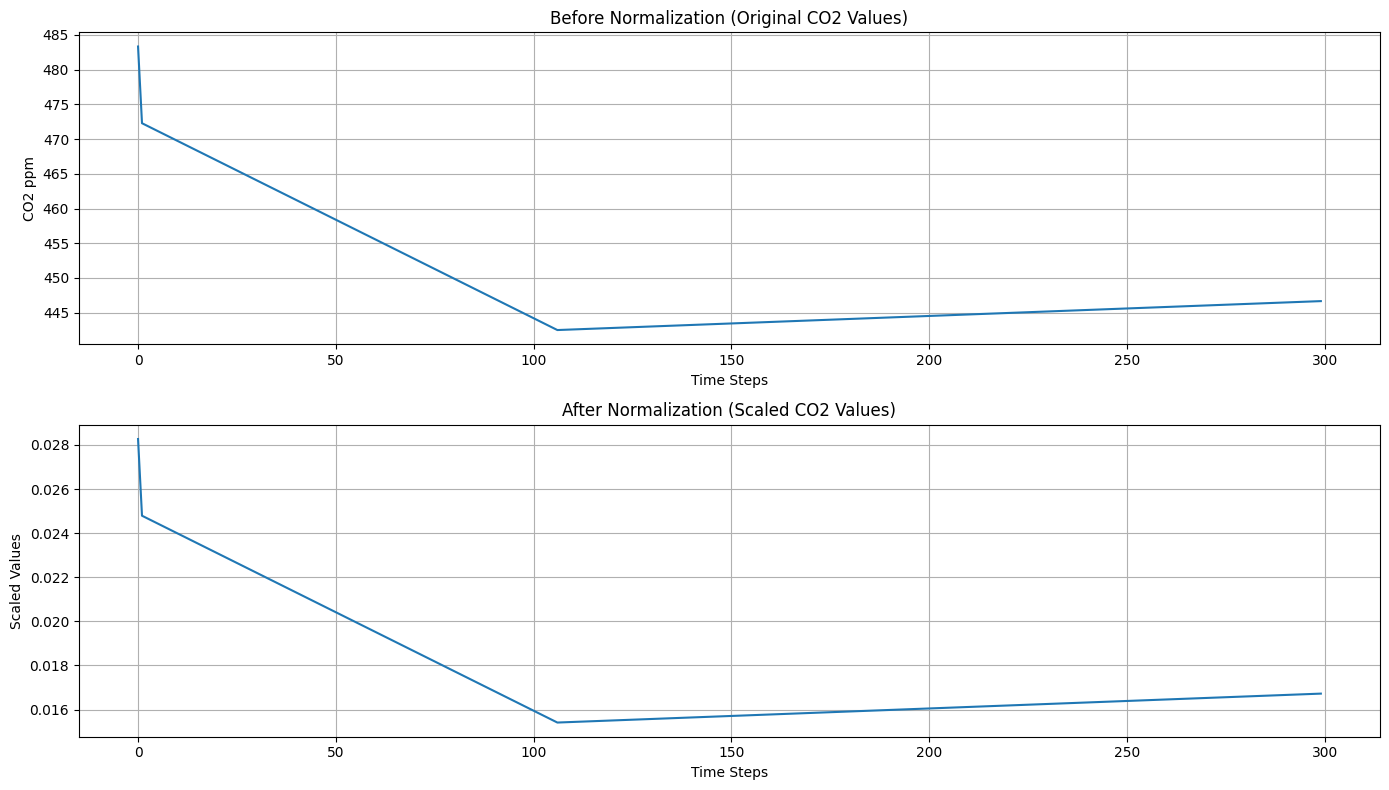


Original CO2 Range:
Min: 393.57142857142856
Max: 3568.9333333333334

Normalized CO2 Range:
Min: 0.0
Max: 0.9999999999999999

Sample Normalized Data:

[[0.07692308 0.00262835 0.66264059 0.69152697 0.31619735 0.35684166
  0.02826824 0.01795688 0.36642707 1.         0.35689587 0.        ]
 [0.07692308 0.00201686 0.66264059 0.69152697 0.32688945 0.35343745
  0.02478908 0.01463808 0.37909097 1.         0.35689587 0.        ]]


In [9]:
# Target feature
feature_name = "scd41_co2"

# Index of target feature
feature_index = feature_columns.index(feature_name)

# Create comparison plots
fig, axes = plt.subplots(2,1,figsize=(14, 8))

# Before normalization
axes[0].plot(train_features[feature_name].iloc[:300].values)
axes[0].set_title("Before Normalization (Original CO2 Values)")
axes[0].set_ylabel("CO2 ppm")
axes[0].set_xlabel("Time Steps")
axes[0].grid(True)

# After normalization
axes[1].plot(train_scaled[:300, feature_index])
axes[1].set_title("After Normalization (Scaled CO2 Values)")
axes[1].set_ylabel("Scaled Values")
axes[1].set_xlabel("Time Steps")
axes[1].grid(True)
plt.tight_layout()
plt.show()

# Print scaling statistics
print("\nOriginal CO2 Range:")
print("Min:", train_features[feature_name].min())
print("Max:", train_features[feature_name].max())

print("\nNormalized CO2 Range:")
print("Min:", train_scaled[:, feature_index].min())
print("Max:", train_scaled[:, feature_index].max())

# Display sample normalized rows
print("\nSample Normalized Data:\n")
print(train_scaled[:2])

## Create Time Series Sequences

In [10]:
# Input sequence length
SEQ_LENGTH = 48

# Forecast horizon
OUTPUT_LENGTH = 6

# Target feature
TARGET = "scd41_co2"

target_index = feature_columns.index(TARGET)

# Sequence generation function
def create_sequences(
    data,
    seq_length,
    output_length,
    target_index
):

    X = []
    y = []
    for i in range(
        len(data)
        - seq_length
        - output_length
    ):

        # Input sequence
        X.append(

            data[
                i : i + seq_length
            ]
        )

        # Multi-step targets
        y.append(

            data[
                i + seq_length :

                i + seq_length + output_length,

                target_index
            ]
        )

    return np.array(X), np.array(y)


# Generate sequences
X_train, y_train = create_sequences(
    train_scaled,
    SEQ_LENGTH,
    OUTPUT_LENGTH,
    target_index
)

X_val, y_val = create_sequences(
    val_scaled,
    SEQ_LENGTH,
    OUTPUT_LENGTH,
    target_index
)

X_test, y_test = create_sequences(
    test_scaled,
    SEQ_LENGTH,
    OUTPUT_LENGTH,
    target_index
)

# Print shapes
print("X_train shape :", X_train.shape)
print("y_train shape :", y_train.shape)
print("\nX_val shape   :", X_val.shape)
print("y_val shape   :", y_val.shape)
print("\nX_test shape  :", X_test.shape)
print("y_test shape  :", y_test.shape)

X_train shape : (113474, 48, 12)
y_train shape : (113474, 6)

X_val shape   : (44109, 48, 12)
y_val shape   : (44109, 6)

X_test shape  : (29149, 48, 12)
y_test shape  : (29149, 6)


## Convert Data to PyTorch Tensors

In [11]:
# Device configuration
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)
print("Using Device:", device)

# Convert training data
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)

# Convert validation data
X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)

# Convert testing data
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

# Print tensor shapes
print("X_train tensor shape :", X_train.shape)
print("y_train tensor shape :", y_train.shape)
print("\nX_val tensor shape   :", X_val.shape)
print("y_val tensor shape   :", y_val.shape)
print("\nX_test tensor shape  :", X_test.shape)
print("y_test tensor shape  :", y_test.shape)

Using Device: cpu
X_train tensor shape : torch.Size([113474, 48, 12])
y_train tensor shape : torch.Size([113474, 6])

X_val tensor shape   : torch.Size([44109, 48, 12])
y_val tensor shape   : torch.Size([44109, 6])

X_test tensor shape  : torch.Size([29149, 48, 12])
y_test tensor shape  : torch.Size([29149, 6])


## Create Optimized DataLoaders

In [12]:
# Common DataLoader parameters
BATCH_SIZE = 32

loader_params = {
    "batch_size": BATCH_SIZE,
    "num_workers": 2,
    "pin_memory": False # needs to be true for NVIDIA CUDA GPUs
}

# Create DataLoaders
train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    shuffle=True,
    **loader_params
)
val_loader = DataLoader(
    TensorDataset(X_val, y_val),
    shuffle=False,
    **loader_params
)
test_loader = DataLoader(
    TensorDataset(X_test, y_test),
    shuffle=False,
    **loader_params
)

# Check one batch
for X_batch, y_batch in train_loader:

    print("Batch X shape :", X_batch.shape)
    print("Batch y shape :", y_batch.shape)

    break

Batch X shape : torch.Size([32, 48, 12])
Batch y shape : torch.Size([32, 6])


## Positional Encoding Layer

In [55]:
class PositionalEncoding(nn.Module):

    def __init__(
        self,
        d_model,
        max_len=5000
    ):

        super().__init__()

        # Create positional encoding matrix
        pe = torch.zeros(max_len, d_model)

        # Position indices
        position = torch.arange(0, max_len).unsqueeze(1)

        # Exponential scaling term
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-np.log(10000.0) / d_model))

        # Apply sine to even indices
        pe[:, 0::2] = torch.sin(position * div_term)

        # Apply cosine to odd indices
        pe[:, 1::2] = torch.cos(position * div_term)

        # Add batch dimension
        pe = pe.unsqueeze(0)

        # Register as non-trainable buffer
        self.register_buffer("pe", pe)

    def forward(self, x):

        # Add positional encoding
        x = x + self.pe[:, :x.size(1)]

        return x

## Transformer Forecasting Model

In [5]:
class TransformerModel(nn.Module):

    def __init__(
        self,
        input_dim,
        output_length,
        d_model=64,
        nhead=4,
        num_layers=2,
        dropout=0.1
    ):
        
        super().__init__()

        # Input projection layer
        self.input_projection = nn.Linear(input_dim, d_model)

        # Positional encoding
        self.positional_encoding = PositionalEncoding(d_model)

        # Transformer encoder layer
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dropout=dropout,
            batch_first=True
        )

        # Transformer encoder
        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )
    
        # Dropout layer
        self.dropout = nn.Dropout(dropout)

        # Final prediction layer
        self.fc = nn.Linear(d_model, output_length)

    def forward(self, x):

        # Input projection
        x = self.input_projection(x)

        # Add positional encoding
        x = self.positional_encoding(x)

        # Transformer encoder
        x = self.transformer_encoder(x)

        # Global average pooling
        x = x.mean(dim=1)

        # Dropout
        x = self.dropout(x)

        # Final prediction
        x = self.fc(x)

        return x

## Initialize Transformer Model

In [6]:
# Initialize model
model = TransformerModel(
    input_dim=len(feature_columns),
    output_length=OUTPUT_LENGTH
)

# Print model architecture
print(model)

NameError: name 'feature_columns' is not defined

## Loss Function Optimizer and Scheduler

In [16]:
# Loss function
criterion = nn.HuberLoss()

# Optimizer
optimizer = optim.AdamW(
    model.parameters(),
    lr=0.0005,
    weight_decay=1e-5
)

# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    patience=3,
    factor=0.5
)

# Training epochs
EPOCHS = 10
print("Loss function initialized : HuberLoss")
print("Optimizer initialized     : AdamW")
print("Scheduler initialized     : ReduceLROnPlateau")

#Device checking
print(device)
print(torch.backends.mps.is_available())
print(torch.backends.mps.is_built())

Loss function initialized : HuberLoss
Optimizer initialized     : AdamW
Scheduler initialized     : ReduceLROnPlateau
cpu
True
True


## Transformer Training Loop

In [17]:
train_losses = []
val_losses = []

# Training loop
for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0

    # Training batches
    for X_batch, y_batch in train_loader:

        # Move data to device
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        # Clear gradients
        optimizer.zero_grad()

        # Forward pass
        predictions = model(X_batch)

        # Compute loss
        loss = criterion(
            predictions,
            y_batch
        )

        # Backpropagation
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        # Update weights
        optimizer.step()

        # Accumulate training loss
        train_loss += loss.item()

    # Average training loss
    avg_train_loss = (train_loss / len(train_loader))

    # Validation phase
    model.eval()
    val_loss = 0.0
    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            # Move to device
            X_batch = X_batch.to(device)

            y_batch = y_batch.to(device)

            # Forward pass
            predictions = model(X_batch)

            # Validation loss
            loss = criterion(
                predictions,
                y_batch
            )
            val_loss += loss.item()

    # Average validation loss
    avg_val_loss = (val_loss / len(val_loader))

    # Store losses
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    # Scheduler step
    scheduler.step(avg_val_loss)

    # Print epoch results
    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Train Loss: {avg_train_loss:.6f} | "
        f"Validation Loss: {avg_val_loss:.6f}"
    )

Epoch [1/10] | Train Loss: 0.001321 | Validation Loss: 0.001267
Epoch [2/10] | Train Loss: 0.000584 | Validation Loss: 0.000987
Epoch [3/10] | Train Loss: 0.000540 | Validation Loss: 0.000608
Epoch [4/10] | Train Loss: 0.000497 | Validation Loss: 0.000623
Epoch [5/10] | Train Loss: 0.000471 | Validation Loss: 0.000608
Epoch [6/10] | Train Loss: 0.000448 | Validation Loss: 0.000541
Epoch [7/10] | Train Loss: 0.000440 | Validation Loss: 0.000566
Epoch [8/10] | Train Loss: 0.000427 | Validation Loss: 0.000644
Epoch [9/10] | Train Loss: 0.000418 | Validation Loss: 0.000618
Epoch [10/10] | Train Loss: 0.000411 | Validation Loss: 0.000620


## Model Evaluation

In [18]:
# Set model to evaluation mode
model.eval()
predictions = []

# Disable gradient calculation
with torch.no_grad():
    for X_batch, y_batch in test_loader:

        # Move batch to device
        X_batch = X_batch.to(device)

        # Model predictions
        outputs = model(X_batch)

        # Move predictions to CPU
        predictions.extend(outputs.cpu().numpy())

# Convert predictions to NumPy array
predictions = np.array(predictions)

# Actual target values
actual = y_test.numpy()

# Evaluation metrics
mse = mean_squared_error(actual, predictions)
rmse = np.sqrt(mse)
mae = mean_absolute_error(actual,predictions)

# Print results
print("\nTransformer Model Evaluation Metrics\n")
print(f"MSE  : {mse:.6f}")
print(f"RMSE : {rmse:.6f}")
print(f"MAE  : {mae:.6f}")


Transformer Model Evaluation Metrics

MSE  : 0.001613
RMSE : 0.040165
MAE  : 0.021558


## Actual vs Predicted Visualization

In [ ]:
PLOT_SIZE = 1000

# Convert arrays to 2D so this works for OUTPUT_LENGTH = 1, 6, 12, 24, etc.
actual_2d = np.asarray(actual)
predictions_2d = np.asarray(predictions)

if actual_2d.ndim == 1:
    actual_2d = actual_2d.reshape(-1, 1)

if predictions_2d.ndim == 1:
    predictions_2d = predictions_2d.reshape(-1, 1)

horizon = predictions_2d.shape[1]

# Actual CO2 is the real measured CO2 signal.
# It stays the same signal; for each graph it is aligned to the selected prediction horizon.
# If you change OUTPUT_LENGTH later, change this list also if needed.
horizons_to_plot = [1, 6]

for horizon_to_compare in horizons_to_plot:

    # Create one separate graph for each horizon.
    plt.figure(figsize=(14, 6))

    # Plot only if this horizon exists in the model output.
    if horizon >= horizon_to_compare:

        horizon_index = horizon_to_compare - 1

        # Actual values
        actual_co2 = actual_2d[:, horizon_index]

        # Predicted values
        predicted_co2 = predictions_2d[:, horizon_index]

        plot_size = min(PLOT_SIZE, len(actual_co2), len(predicted_co2))
        time_steps = np.arange(plot_size)

        plt.plot(
            time_steps,
            actual_co2[:plot_size],
            label="Actual CO2",
            linewidth=2,
            marker="o",
            markevery=50,
            markersize=4
        )

        plt.plot(
            time_steps,
            predicted_co2[:plot_size],
            label=f"Predicted CO2 (Horizon {horizon_to_compare})",
            linewidth=2,
            linestyle="--",
            marker="x",
            markevery=50,
            markersize=5
        )

        # Highlight the first and last plotted points.
        plt.scatter(
            [time_steps[0], time_steps[-1]],
            [actual_co2[:plot_size][0], actual_co2[:plot_size][-1]],
            s=60,
            zorder=5
        )

        plt.scatter(
            [time_steps[0], time_steps[-1]],
            [predicted_co2[:plot_size][0], predicted_co2[:plot_size][-1]],
            s=60,
            zorder=5
        )

        # Plot formatting
        plt.title(f"Transformer Forecasting: Actual vs Predicted CO2 - Horizon {horizon_to_compare}")
        plt.xlabel("Time Steps")
        plt.ylabel("Normalized CO2")
        plt.legend()
        plt.grid(True, alpha=0.35)

    else:

        # Plot formatting when the requested horizon is not available.
        plt.title(f"Horizon {horizon_to_compare} Not Available")
        plt.text(
            0.5,
            0.5,
            f"OUTPUT_LENGTH = {horizon}\nTrain with OUTPUT_LENGTH >= {horizon_to_compare}",
            ha="center",
            va="center",
            transform=plt.gca().transAxes,
            fontsize=12
        )
        plt.xlabel("Time Steps")
        plt.ylabel("Normalized CO2")
        plt.grid(True, alpha=0.35)

    plt.tight_layout()
    plt.show()


## Training and Validation Loss Visualization

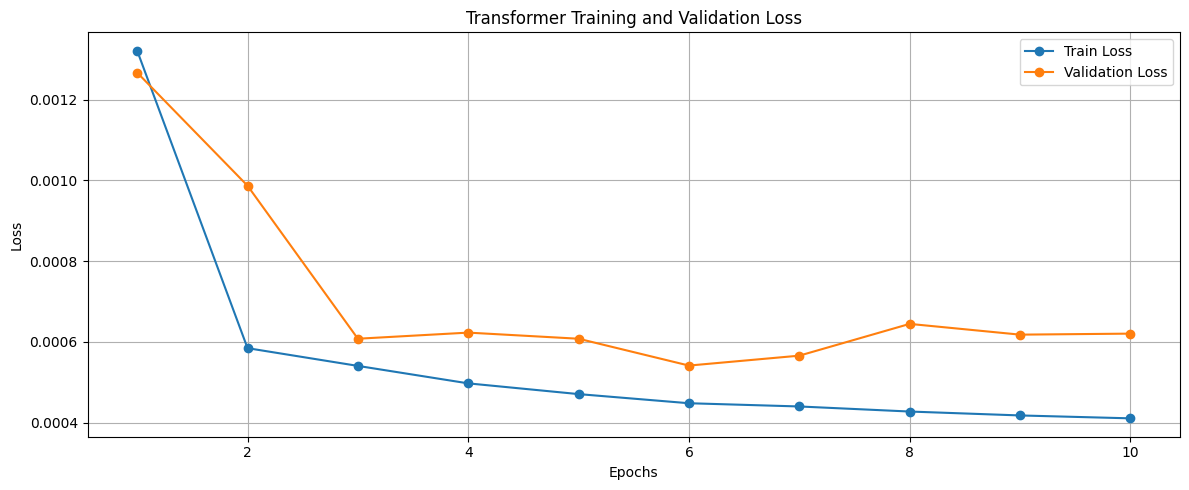

In [ ]:
plt.figure(figsize=(12, 5))

# Training loss
plt.plot(
    range(1, EPOCHS + 1),
    train_losses,
    marker="o",
    label="Train Loss"
)

# Validation loss
plt.plot(
    range(1, EPOCHS + 1),
    val_losses,
    marker="o",
    label="Validation Loss"
)

# Plot formatting
plt.title("Transformer Training and Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 1.1Timestamp compares

In [ ]:
class CustomMultiHeadAttention(nn.Module):

    def __init__(
        self,
        d_model,
        nhead
    ):

        super().__init__()

        # Save parameters
        self.d_model = d_model
        self.nhead = nhead

        # Dimension per head
        self.head_dim = d_model // nhead

        # Safety check to understand evey dimension divide correctly
        assert (
            self.head_dim * nhead == d_model
        ), "d_model must be divisible by nhead"

        # Query projection
        self.W_q = nn.Linear(
            d_model,
            d_model
        )

        # Key projection
        self.W_k = nn.Linear(
            d_model,
            d_model
        )

        # Value projection
        self.W_v = nn.Linear(
            d_model,
            d_model
        )

        # Output projection
        self.W_o = nn.Linear(
            d_model,
            d_model
        )

    def forward(self, x):

        batch_size = x.size(0)
        seq_len = x.size(1)

        # Generate Q K V
        Q = self.W_q(x)
        K = self.W_k(x)
        V = self.W_v(x)

        # Split into heads
        Q = Q.view(
            batch_size,
            seq_len,
            self.nhead,
            self.head_dim
        ).transpose(1, 2)

        K = K.view(
            batch_size,
            seq_len,
            self.nhead,
            self.head_dim
        ).transpose(1, 2)

        V = V.view(
            batch_size,
            seq_len,
            self.nhead,
            self.head_dim
        ).transpose(1, 2)

        # Attention scores
        scores = torch.matmul(
            Q,
            K.transpose(-2, -1)
        )

        scores = scores / np.sqrt(
            self.head_dim
        )

        # Softmax
        attention_weights = torch.softmax(
            scores,
            dim=-1
        )

        # Weighted sum
        attention_output = torch.matmul(
            attention_weights,
            V
        )

        # Combine heads
        attention_output = (
            attention_output
            .transpose(1, 2)
            .contiguous()
            .view(
                batch_size,
                seq_len,
                self.d_model
            )
        )

        # Final projection
        output = self.W_o(
            attention_output
        )

        return output, attention_weights

## 1.2 . Immediate Validation Test

In [12]:
sample_input = torch.randn(
    8,
    24,
    64
)

attention_layer = CustomMultiHeadAttention(
    d_model=64,
    nhead=4
)

output, weights = attention_layer(
    sample_input
)

print("Output Shape:")
print(output.shape)

print("\nAttention Shape:")
print(weights.shape)

Output Shape:
torch.Size([8, 24, 64])

Attention Shape:
torch.Size([8, 4, 24, 24])


## 2. Build Custom Transformer Encoder Layer

In [13]:
class CustomTransformerEncoderLayer(nn.Module):

    def __init__(
        self,
        d_model,
        nhead,
        dim_feedforward=256,
        dropout=0.1
    ):

        super().__init__()

        # Custom Attention
        self.self_attention = CustomMultiHeadAttention(
            d_model=d_model,
            nhead=nhead
        )

        # Layer Normalization
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

        # Dropout
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)

        # Feed Forward Network
        self.feed_forward = nn.Sequential(
            nn.Linear(d_model, dim_feedforward),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(dim_feedforward, d_model)
        )

    def forward(self, x):

        # Attention Block
        attention_output, attention_weights = self.self_attention(x)

        # Residual Connection + LayerNorm
        x = self.norm1(
            x + self.dropout1(attention_output)
        )

        # Feed Forward Block
        ff_output = self.feed_forward(x)

        # Residual Connection + LayerNorm
        output = self.norm2(
            x + self.dropout2(ff_output)
        )

        return output, attention_weights

In [14]:
encoder_layer = CustomTransformerEncoderLayer(
    d_model=64,
    nhead=4
)

sample_input = torch.randn(
    8,
    24,
    64
)

output, attention_weights = encoder_layer(
    sample_input
)

print("Output Shape:")
print(output.shape)

print("\nAttention Shape:")
print(attention_weights.shape)

Output Shape:
torch.Size([8, 24, 64])

Attention Shape:
torch.Size([8, 4, 24, 24])


## 3 Custom Transformer Encoder Stack

In [15]:
class CustomTransformerEncoder(nn.Module):

    def __init__(
        self,
        num_layers,
        d_model,
        nhead,
        dim_feedforward=256,
        dropout=0.1
    ):

        super().__init__()

        self.layers = nn.ModuleList([
            CustomTransformerEncoderLayer(
                d_model=d_model,
                nhead=nhead,
                dim_feedforward=dim_feedforward,
                dropout=dropout
            )
            for _ in range(num_layers)
        ])

    def forward(self, x):

        all_attention_weights = []

        for layer in self.layers:

            x, attention_weights = layer(x)

            all_attention_weights.append(
                attention_weights
            )

        return x, all_attention_weights

In [16]:
encoder = CustomTransformerEncoder(
    num_layers=2,
    d_model=64,
    nhead=4
)

sample_input = torch.randn(
    8,
    24,
    64
)

output, attention_list = encoder(
    sample_input
)

print("Output Shape:")
print(output.shape)

print("\nNumber of Layers:")
print(len(attention_list))

print("\nLayer 1 Shape:")
print(attention_list[0].shape)

print("\nLayer 2 Shape:")
print(attention_list[1].shape)


Output Shape:
torch.Size([8, 24, 64])

Number of Layers:
2

Layer 1 Shape:
torch.Size([8, 4, 24, 24])

Layer 2 Shape:
torch.Size([8, 4, 24, 24])


## 4 — Explainable Transformer Forecasting Model

In [20]:
class ExplainableTransformerModel(nn.Module):

    def __init__(
        self,
        input_dim,
        output_length,
        d_model=64,
        nhead=4,
        num_layers=2,
        dropout=0.1
    ):

        super().__init__()

        # Input projection
        self.input_projection = nn.Linear(
            input_dim,
            d_model
        )

        # Positional encoding
        self.positional_encoding = PositionalEncoding(
            d_model
        )

        # Custom encoder
        self.transformer_encoder = CustomTransformerEncoder(
            num_layers=num_layers,
            d_model=d_model,
            nhead=nhead,
            dropout=dropout
        )

        # Dropout
        self.dropout = nn.Dropout(
            dropout
        )

        # Forecast head
        self.fc = nn.Linear(
            d_model,
            output_length
        )

    def forward(self, x):

        # Input projection
        x = self.input_projection(x)

        # Positional encoding
        x = self.positional_encoding(x)

        # Custom encoder
        x, attention_list = self.transformer_encoder(x)

        # Global average pooling
        x = x.mean(dim=1)

        # Dropout
        x = self.dropout(x)

        # Final prediction
        prediction = self.fc(x)

        return prediction, attention_list

In [56]:
model = ExplainableTransformerModel(
    input_dim=5,
    output_length=1,
    d_model=64,
    nhead=4,
    num_layers=2
)

sample_input = torch.randn(
    8,
    24,
    5
)

prediction, attention_list = model(
    sample_input
)

print("Prediction Shape:")
print(prediction.shape)

print()

print("Number of Layers:")
print(len(attention_list))

print()

print("Layer 1 Shape:")
print(attention_list[0].shape)

print()

print("Layer 2 Shape:")
print(attention_list[1].shape)

Prediction Shape:
torch.Size([8, 1])

Number of Layers:
2

Layer 1 Shape:
torch.Size([8, 4, 24, 24])

Layer 2 Shape:
torch.Size([8, 4, 24, 24])


## 5. Attention Validation

## Objective

Before performing explainability analysis, we must verify that the extracted attention weights are mathematically valid.

The following checks will be performed:

1. Verify tensor dimensions
2. Verify attention values are between 0 and 1
3. Verify each attention row sums to 1
4. Verify absence of NaN values

These validations ensure that the attention mechanism is functioning correctly and that subsequent explainability analyses are reliable.

In [22]:
# ==========================================================
# Attention Structure Verification
# ==========================================================

print("Number of Layers:", len(attention_weights))

for layer_idx, layer_attention in enumerate(attention_weights):

    print(f"\nLayer {layer_idx + 1}")

    print("Shape:", layer_attention.shape)

    batch_size = layer_attention.shape[0]
    num_heads = layer_attention.shape[1]
    seq_len = layer_attention.shape[2]

    print("Batch Size :", batch_size)
    print("Heads      :", num_heads)
    print("Sequence   :", seq_len)

Number of Layers: 8

Layer 1
Shape: torch.Size([4, 24, 24])
Batch Size : 4
Heads      : 24
Sequence   : 24

Layer 2
Shape: torch.Size([4, 24, 24])
Batch Size : 4
Heads      : 24
Sequence   : 24

Layer 3
Shape: torch.Size([4, 24, 24])
Batch Size : 4
Heads      : 24
Sequence   : 24

Layer 4
Shape: torch.Size([4, 24, 24])
Batch Size : 4
Heads      : 24
Sequence   : 24

Layer 5
Shape: torch.Size([4, 24, 24])
Batch Size : 4
Heads      : 24
Sequence   : 24

Layer 6
Shape: torch.Size([4, 24, 24])
Batch Size : 4
Heads      : 24
Sequence   : 24

Layer 7
Shape: torch.Size([4, 24, 24])
Batch Size : 4
Heads      : 24
Sequence   : 24

Layer 8
Shape: torch.Size([4, 24, 24])
Batch Size : 4
Heads      : 24
Sequence   : 24


## 6. Attention Value Range Validation

Because attention weights are produced by a Softmax operation,
all values should lie between 0 and 1.

In [23]:
# ==========================================================
# Attention Value Range Check
# ==========================================================

for layer_idx, layer_attention in enumerate(attention_weights):

    min_value = layer_attention.min().item()
    max_value = layer_attention.max().item()

    print(f"\nLayer {layer_idx + 1}")

    print("Minimum:", min_value)
    print("Maximum:", max_value)


Layer 1
Minimum: 0.011627625674009323
Maximum: 0.14309902489185333

Layer 2
Minimum: 0.008590166456997395
Maximum: 0.15059372782707214

Layer 3
Minimum: 0.009537851437926292
Maximum: 0.14668607711791992

Layer 4
Minimum: 0.00804123841226101
Maximum: 0.15657220780849457

Layer 5
Minimum: 0.013110962696373463
Maximum: 0.1166331097483635

Layer 6
Minimum: 0.007208443712443113
Maximum: 0.13695931434631348

Layer 7
Minimum: 0.010233001783490181
Maximum: 0.12327317148447037

Layer 8
Minimum: 0.010665493085980415
Maximum: 0.12254393845796585


## 7. Attention Row Sum Validation

Each row of an attention matrix represents a probability distribution.

Therefore, the sum of each row should be approximately equal to 1.

In [24]:
# ==========================================================
# Row Sum Verification
# ==========================================================

for layer_idx, layer_attention in enumerate(attention_weights):

    row_sums = layer_attention.sum(dim=-1)

    mean_row_sum = row_sums.mean().item()
    min_row_sum = row_sums.min().item()
    max_row_sum = row_sums.max().item()

    print(f"\nLayer {layer_idx + 1}")

    print("Mean Row Sum:", mean_row_sum)
    print("Min Row Sum :", min_row_sum)
    print("Max Row Sum :", max_row_sum)


Layer 1
Mean Row Sum: 1.0
Min Row Sum : 0.9999998211860657
Max Row Sum : 1.000000238418579

Layer 2
Mean Row Sum: 1.0
Min Row Sum : 0.9999998807907104
Max Row Sum : 1.000000238418579

Layer 3
Mean Row Sum: 1.0
Min Row Sum : 0.9999998211860657
Max Row Sum : 1.000000238418579

Layer 4
Mean Row Sum: 1.0
Min Row Sum : 0.9999997615814209
Max Row Sum : 1.0000001192092896

Layer 5
Mean Row Sum: 1.0
Min Row Sum : 0.9999998211860657
Max Row Sum : 1.0000001192092896

Layer 6
Mean Row Sum: 1.0
Min Row Sum : 0.9999998211860657
Max Row Sum : 1.0000001192092896

Layer 7
Mean Row Sum: 1.0
Min Row Sum : 0.9999998807907104
Max Row Sum : 1.000000238418579

Layer 8
Mean Row Sum: 1.0
Min Row Sum : 0.9999998211860657
Max Row Sum : 1.0000001192092896


## 8. NaN Validation

NaN values indicate numerical instability and would invalidate
the explainability analysis.

In [25]:
# ==========================================================
# NaN Check
# ==========================================================

for layer_idx, layer_attention in enumerate(attention_weights):

    nan_count = torch.isnan(layer_attention).sum().item()

    print(f"Layer {layer_idx + 1}")

    print("NaN Values:", nan_count)

Layer 1
NaN Values: 0
Layer 2
NaN Values: 0
Layer 3
NaN Values: 0
Layer 4
NaN Values: 0
Layer 5
NaN Values: 0
Layer 6
NaN Values: 0
Layer 7
NaN Values: 0
Layer 8
NaN Values: 0


## 9. Attention Statistics Summary Table

This table summarizes the numerical properties of the extracted
attention weights for each Transformer layer.

In [ ]:
# ==========================================================
# Attention Statistics Table
# ==========================================================

import pandas as pd

statistics = []

for layer_idx, layer_attention in enumerate(attention_weights):

    statistics.append({
        "Layer": layer_idx + 1,
        "Minimum": layer_attention.min().item(),
        "Maximum": layer_attention.max().item(),
        "Mean": layer_attention.mean().item(),
        "Std": layer_attention.std().item(),
        "NaN Count": torch.isnan(layer_attention).sum().item()
    })

attention_stats_df = pd.DataFrame(statistics)

attention_stats_df

,Layer,Minimum,Maximum,Mean,Std,NaN Count
0,1,0.011628,0.143099,0.041667,0.013287,0
1,2,0.008590,0.150594,0.041667,0.013677,0
2,3,0.009538,0.146686,0.041667,0.014382,0
3,4,0.008041,0.156572,0.041667,0.015758,0
4,5,0.013111,0.116633,0.041667,0.012759,0
5,6,0.007208,0.136959,0.041667,0.013170,0
6,7,0.010233,0.123273,0.041667,0.013974,0
7,8,0.010665,0.122544,0.041667,0.013649,0


## 10. Random Forecast Attention Analysis

The purpose of this analysis is to investigate how the Transformer
allocates attention across historical timesteps for a single forecast.

A randomly selected test sample will be analyzed.

The corresponding attention matrix will be extracted and visualized.

Research Questions:

1. Which historical timestamps receive the highest attention?
2. Does the model focus on recent observations?
3. Are long-range temporal dependencies present?

In [26]:
# ==========================================================
# Select Sample and Head
# ==========================================================

sample_idx = 0
head_idx = 0

attention_map = attention_weights[sample_idx, head_idx]

print("Attention Map Shape:")
print(attention_map.shape)

# ==========================================================
# Attention Map Statistics
# ==========================================================

print("Minimum :", attention_map.min().item())
print("Maximum :", attention_map.max().item())
print("Mean    :", attention_map.mean().item())
print("Std     :", attention_map.std().item())

Attention Map Shape:
torch.Size([24, 24])
Minimum : 0.011627625674009323
Maximum : 0.10325517505407333
Mean    : 0.0416666679084301
Std     : 0.013548018410801888


## 11. Historical Timestep Importance

The total attention received by each timestep is computed by
summing attention across all query positions.

Higher values indicate that the timestep contributes more
strongly to the model's internal decision process.

In [28]:
# ==========================================================
# Timestep Importance
# ==========================================================

import pandas as pd

importance_scores = attention_map.sum(dim=0)

importance_df = pd.DataFrame({
    "Timestep": range(24),
    "Importance": importance_scores.detach().cpu().numpy()
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(10)

,Timestep,Importance
3,3,1.220774
1,1,1.099009
22,22,1.092842
13,13,1.081139
16,16,1.076926
6,6,1.076882
19,19,1.073399
17,17,1.048502
4,4,1.043772
14,14,1.035043


## 12 Attention Heatmap Visualization

Visualize the attention distribution for a single sample and
a single attention head.

The heatmap illustrates how strongly each query timestep
attends to historical timesteps.

Interpretation:

Rows    → Query timesteps

Columns → Key timesteps

Brighter regions indicate stronger attention.

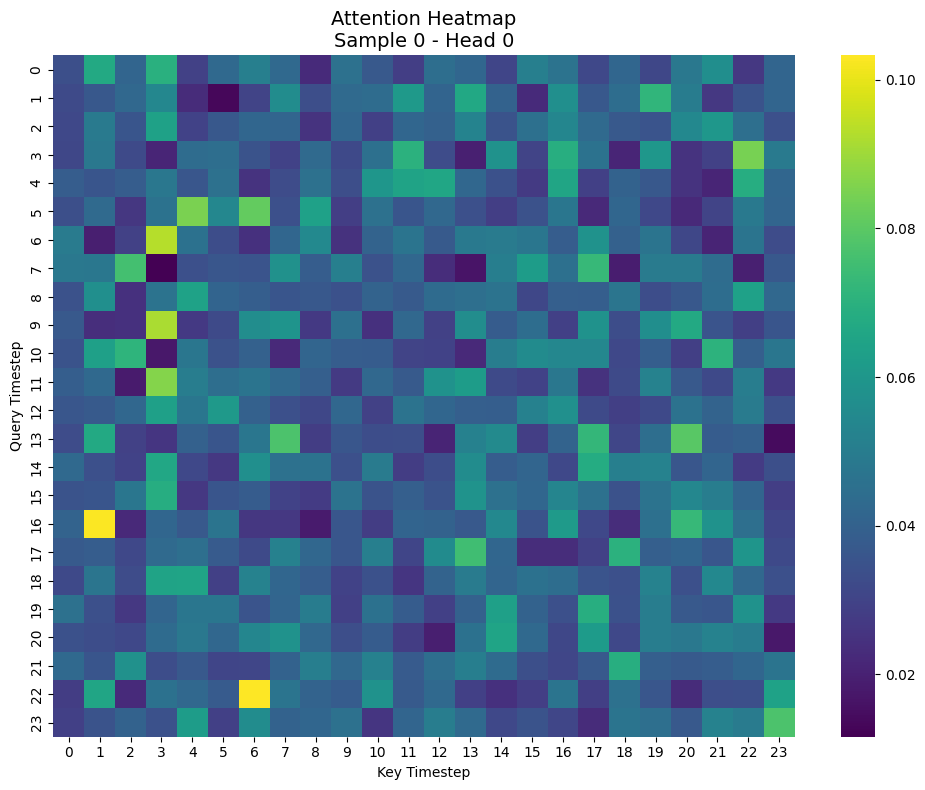

In [59]:
# ==========================================================
# Attention Heatmap
# ==========================================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(
    attention_map.detach().cpu().numpy(),
    cmap="viridis"
)

plt.title(
    "Attention Heatmap\nSample 0 - Head 0",
    fontsize=14
)

plt.xlabel("Key Timestep")
plt.ylabel("Query Timestep")

plt.tight_layout()
plt.show()

## 13. Query-Level Attention Analysis

Determine which query timestep exhibits the strongest
maximum attention value.

In [30]:
# ==========================================================
# Query Focus Analysis
# ==========================================================

max_attention_per_query = attention_map.max(dim=1).values

query_focus_df = pd.DataFrame({
    "Query Timestep": range(24),
    "Maximum Attention": max_attention_per_query.detach().cpu().numpy()
})

query_focus_df.sort_values(
    by="Maximum Attention",
    ascending=False
).head(10)

,Query Timestep,Maximum Attention
22,22,0.103255
16,16,0.102701
6,6,0.093090
9,9,0.091693
11,11,0.086419
5,5,0.084818
3,3,0.084563
13,13,0.079376
23,23,0.077347
7,7,0.075915


## 14 Attention Head Comparison

Multi-head attention allows the Transformer to learn multiple
representations of temporal relationships simultaneously.

This analysis investigates whether different attention heads
focus on different historical patterns.

Research Questions:

1. Do attention heads behave differently?
2. Are some heads redundant?
3. Do certain heads focus on local temporal patterns?
4. Do certain heads focus on long-range temporal patterns?

torch.Size([8, 4, 24, 24])
torch.Size([4, 24, 24])


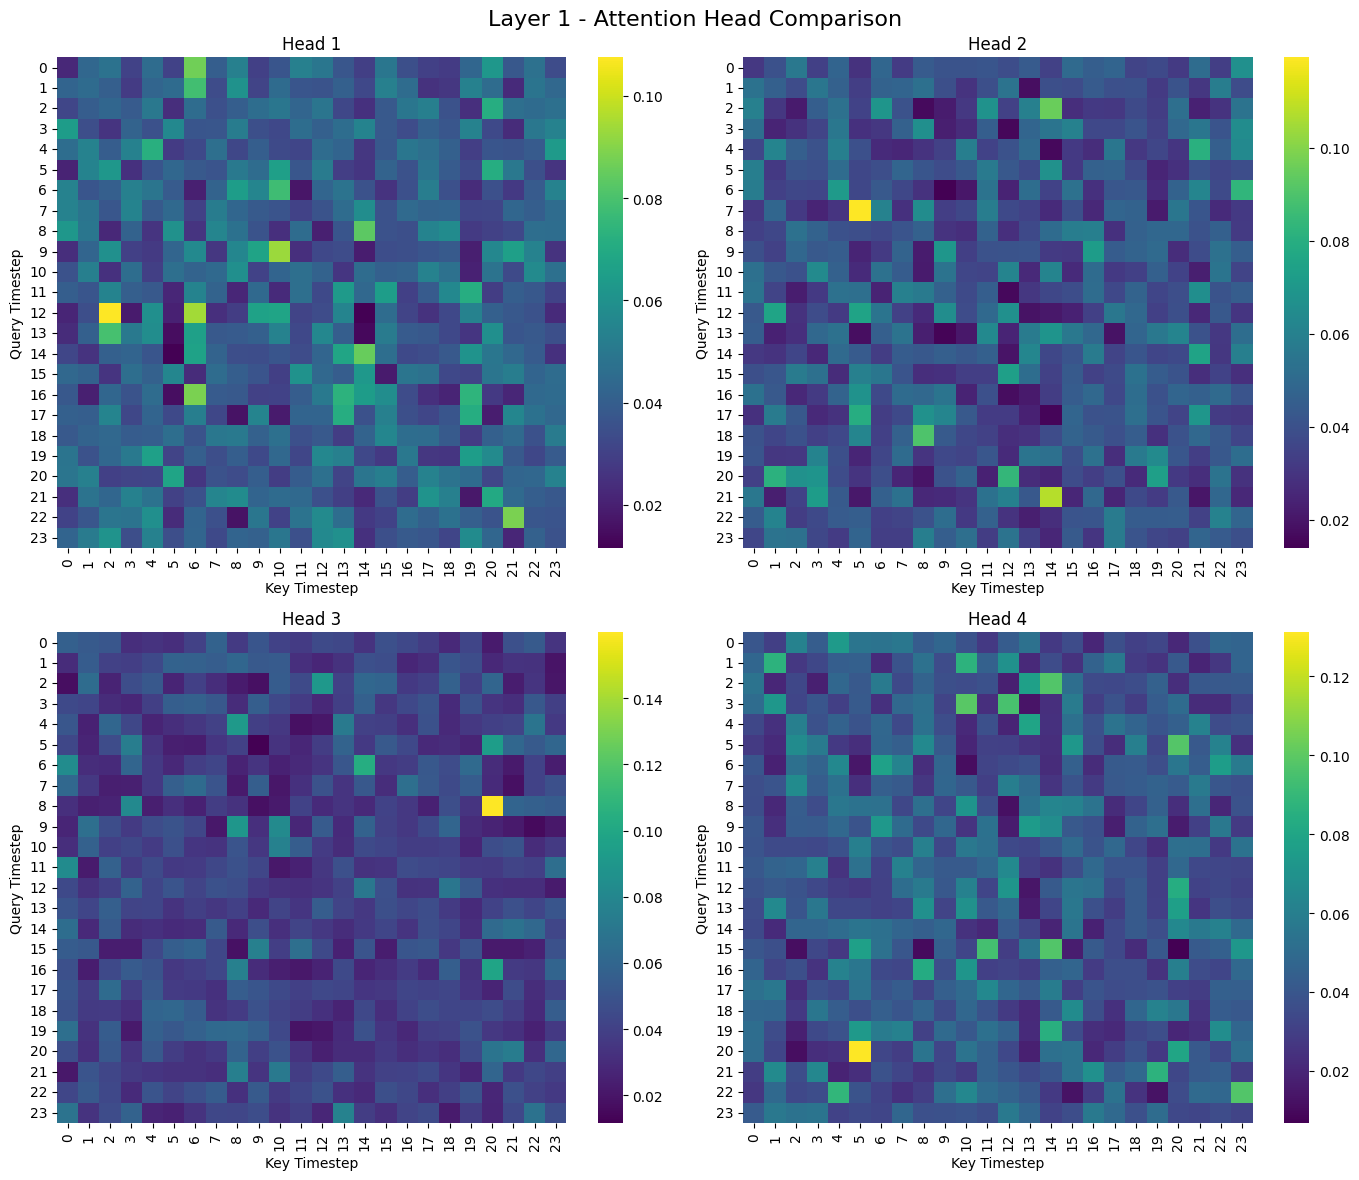

In [ ]:
# ==========================================================
# Select Layer 1
# ==========================================================

layer_1_attention = attention_list[0]

print(layer_1_attention.shape)

# ==========================================================
# Select Sample
# ==========================================================

sample_idx = 0

sample_attention = layer_1_attention[sample_idx]

print(sample_attention.shape)

# ==========================================================
# Compare All Heads
# ==========================================================

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14,12)
)

for head_idx, ax in enumerate(axes.flat):

    sns.heatmap(
        sample_attention[head_idx].detach().cpu().numpy(),
        cmap="viridis",
        ax=ax
    )

    ax.set_title(
        f"Head {head_idx + 1}"
    )

    ax.set_xlabel("Key Timestep")
    ax.set_ylabel("Query Timestep")

plt.suptitle(
    "Layer 1 - Attention Head Comparison",
    fontsize=16
)

plt.tight_layout()

plt.show()



## 15 Head Statistics

In [33]:
# ==========================================================
# Head Statistics
# ==========================================================

import pandas as pd

head_statistics = []

for head_idx in range(4):

    head_attention = sample_attention[head_idx]

    head_statistics.append({

        "Head": head_idx + 1,

        "Mean":
            head_attention.mean().item(),

        "Std":
            head_attention.std().item(),

        "Maximum":
            head_attention.max().item(),

        "Minimum":
            head_attention.min().item()

    })

head_stats_df = pd.DataFrame(
    head_statistics
)

head_stats_df

,Head,Mean,Std,Maximum,Minimum
0,1,0.041667,0.013329,0.107530,0.011588
1,2,0.041667,0.013773,0.119453,0.013914
2,3,0.041667,0.014487,0.159918,0.011652
3,4,0.041667,0.016142,0.131191,0.006787


## 16 Average Attention Across Heads


Each attention head captures different temporal relationships.

To obtain a global view of the Transformer's behavior,
the attention matrices from all heads are averaged.

This average attention map represents the overall temporal
focus pattern learned by the model.

Shape:
torch.Size([24, 24])


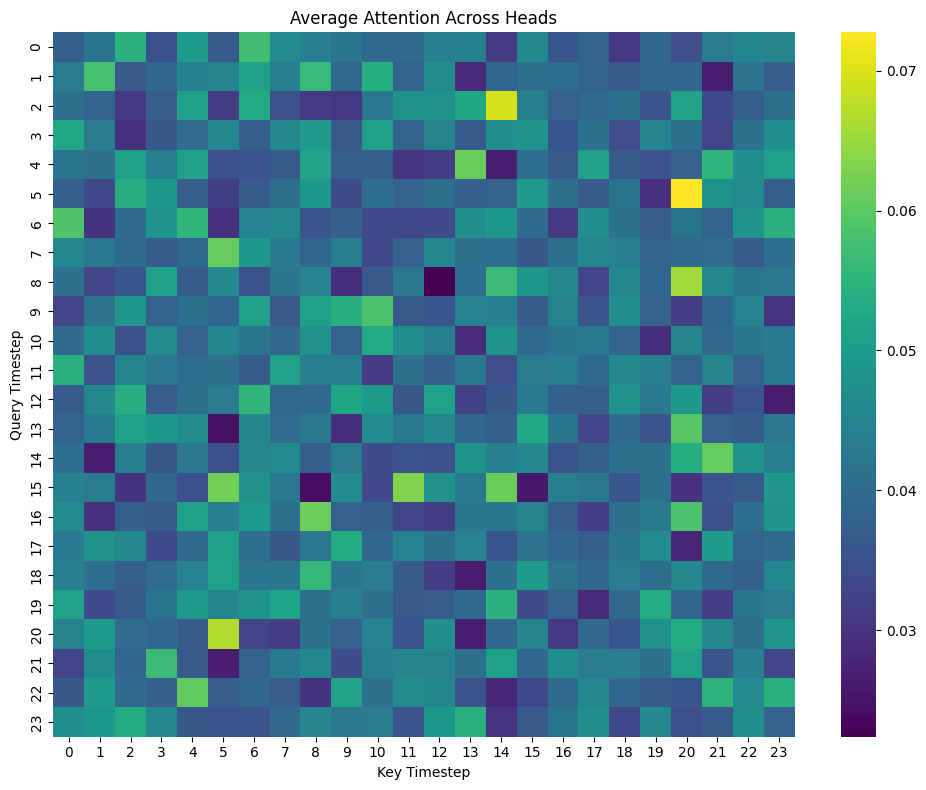

In [34]:
# ==========================================================
# Average Attention Across Heads
# ==========================================================

average_attention = sample_attention.mean(dim=0)

print("Shape:")
print(average_attention.shape)

# ==========================================================
# Save Global Attention Heatmap
# ==========================================================

plt.figure(figsize=(10,8))

sns.heatmap(
    average_attention.detach().cpu().numpy(),
    cmap="viridis"
)

plt.title("Average Attention Across Heads")

plt.xlabel("Key Timestep")
plt.ylabel("Query Timestep")

plt.tight_layout()

plt.savefig(
    "average_attention_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 17 Global Timestep Importance

In [35]:
# ==========================================================
# Global Timestep Importance
# ==========================================================

importance_scores = average_attention.sum(dim=0)

importance_df = pd.DataFrame({

    "Timestep": range(24),

    "Importance":
        importance_scores.detach().cpu().numpy()

})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(10)

,Timestep,Importance
20,20,1.074841
8,8,1.049250
6,6,1.048162
4,4,1.042012
0,0,1.029748
14,14,1.023951
23,23,1.023425
2,2,1.007472
5,5,1.007265
10,10,1.004782


## 18 Layer-Level Attention Analysis

Transformer layers process temporal information progressively.

This analysis compares attention distributions between
Layer 1 and Layer 2 to investigate how temporal reasoning
evolves through network depth.

Research Questions:

1. Does Layer 1 focus on local temporal information?
2. Does Layer 2 focus on broader temporal dependencies?
3. How does attention change across layers?

Number of Stored Layers:
2

Layer 1
torch.Size([8, 4, 24, 24])

Layer 2
torch.Size([8, 4, 24, 24])
Layer 1 Shape:
torch.Size([4, 24, 24])

Layer 2 Shape:
torch.Size([4, 24, 24])
torch.Size([24, 24])
torch.Size([24, 24])


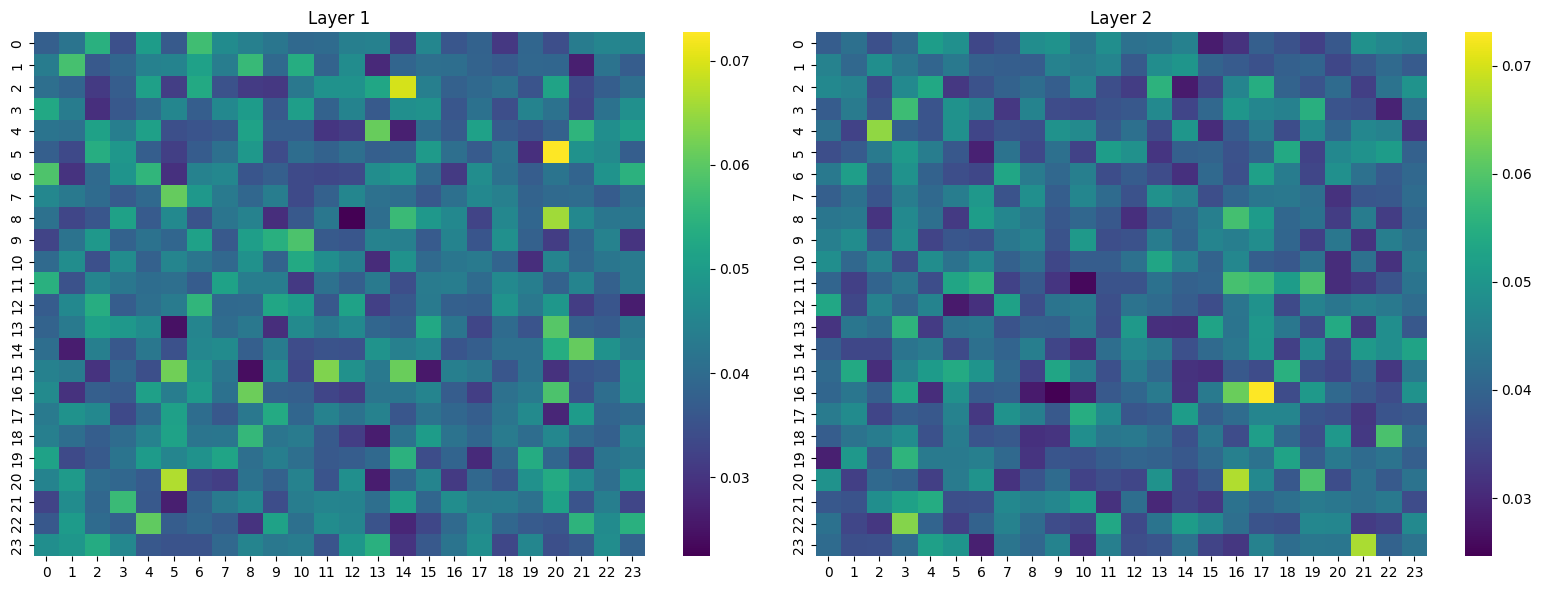

In [36]:
# ==========================================================
# Verify Stored Layers
# ==========================================================

print("Number of Stored Layers:")
print(len(attention_list))

for i, layer_attention in enumerate(attention_list):

    print(f"\nLayer {i+1}")

    print(layer_attention.shape)

# ==========================================================
# Select Sample
# ==========================================================

sample_idx = 0

layer1_sample = attention_list[0][sample_idx]

layer2_sample = attention_list[1][sample_idx]

print("Layer 1 Shape:")
print(layer1_sample.shape)

print("\nLayer 2 Shape:")
print(layer2_sample.shape)

# ==========================================================
# Average Heads
# ==========================================================

layer1_average = layer1_sample.mean(dim=0)

layer2_average = layer2_sample.mean(dim=0)

print(layer1_average.shape)
print(layer2_average.shape)

# ==========================================================
# Layer Comparison Heatmaps
# ==========================================================

# ==========================================================
# Save Layer Comparison Figure
# ==========================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16,6)
)

sns.heatmap(
    layer1_average.detach().cpu().numpy(),
    cmap="viridis",
    ax=axes[0]
)

axes[0].set_title("Layer 1")

sns.heatmap(
    layer2_average.detach().cpu().numpy(),
    cmap="viridis",
    ax=axes[1]
)

axes[1].set_title("Layer 2")

plt.tight_layout()

plt.savefig(
    "layer_comparison_heatmaps.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 19 Numerical Layer Comparison

In [41]:
# ==========================================================
# Layer Statistics
# ==========================================================

import pandas as pd

layer_stats = pd.DataFrame({

    "Layer": [1, 2],

    "Mean": [
        layer1_average.mean().item(),
        layer2_average.mean().item()
    ],

    "Std": [
        layer1_average.std().item(),
        layer2_average.std().item()
    ],

    "Max": [
        layer1_average.max().item(),
        layer2_average.max().item()
    ],

    "Min": [
        layer1_average.min().item(),
        layer2_average.min().item()
    ]

})

layer_stats

,Layer,Mean,Std,Max,Min
0,1,0.041667,0.007373,0.072736,0.022394
1,2,0.041667,0.006918,0.073086,0.024614


In [44]:
# ==========================================================
# Layer Importance Comparison
# ==========================================================

layer1_importance = layer1_average.sum(dim=0)

layer2_importance = layer2_average.sum(dim=0)

importance_comparison = pd.DataFrame({

    "Timestep": range(24),

    "Layer1": layer1_importance.detach().cpu().numpy(),

    "Layer2": layer2_importance.detach().cpu().numpy()

})

importance_comparison.head()

,Timestep,Layer1,Layer2
0,0,1.029748,0.999580
1,1,0.989782,1.001141
2,2,1.007472,0.965711
3,3,0.994466,1.129515
4,4,1.042012,1.010293


## 20. Global Temporal Importance Analysis

Previous analyses focused on individual samples.

This section aggregates attention information across the
entire test dataset to identify the historical timesteps
that consistently influence predictions.

Research Questions:

1. Which historical timesteps are most important overall?
2. Does the model rely primarily on recent observations?
3. Are long-range temporal dependencies present?

In [45]:
# ==========================================================
# Global Attention Aggregation
# ==========================================================

layer1_attention = attention_list[0]

global_attention = layer1_attention.mean(dim=0)

print(global_attention.shape)

# ==========================================================
# Average Across Heads
# ==========================================================

global_attention = global_attention.mean(dim=0)

print(global_attention.shape)

# ==========================================================
# Global Timestep Importance
# ==========================================================

global_importance = global_attention.sum(dim=0)

global_importance_df = pd.DataFrame({

    "Timestep": range(24),

    "Importance":
        global_importance.detach().cpu().numpy()

})

global_importance_df = global_importance_df.sort_values(
    by="Importance",
    ascending=False
)

global_importance_df

torch.Size([4, 24, 24])
torch.Size([24, 24])


,Timestep,Importance
23,23,1.028509
9,9,1.023861
15,15,1.016215
13,13,1.015533
19,19,1.013484
6,6,1.012432
8,8,1.011479
1,1,1.010601
4,4,1.008246
10,10,1.006383


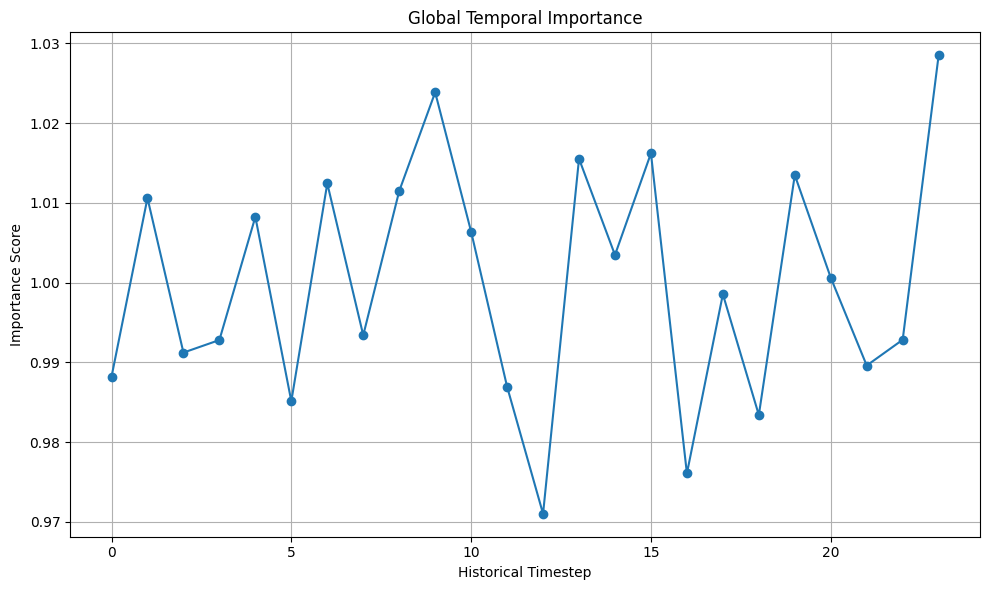

In [46]:
# ==========================================================
# Save Importance Curve
# ==========================================================

plt.figure(figsize=(10,6))

plt.plot(
    range(24),
    global_importance.detach().cpu().numpy(),
    marker='o'
)

plt.title(
    "Global Temporal Importance"
)

plt.xlabel("Historical Timestep")

plt.ylabel("Importance Score")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "global_temporal_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

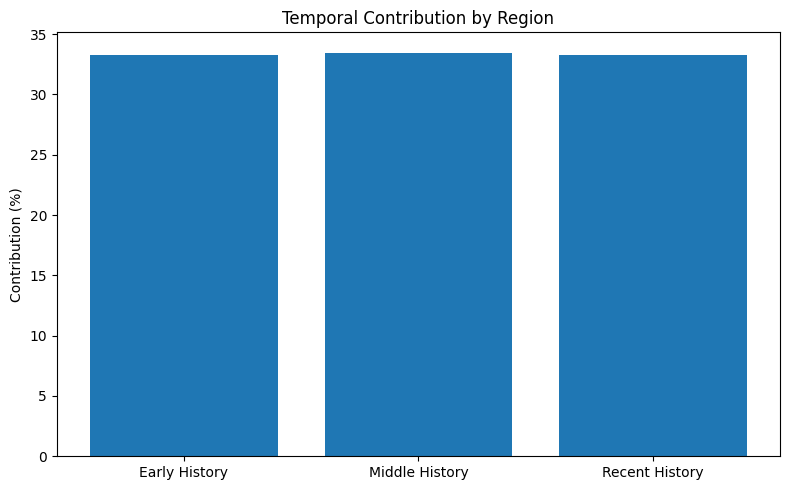

In [47]:
# ==========================================================
# Recency Contribution Analysis
# ==========================================================

importance_values = global_importance.detach().cpu().numpy()

total_importance = importance_values.sum()

early_importance = importance_values[0:8].sum()

middle_importance = importance_values[8:16].sum()

recent_importance = importance_values[16:24].sum()

recency_df = pd.DataFrame({

    "Region": [
        "Early History",
        "Middle History",
        "Recent History"
    ],

    "Contribution (%)": [

        100 * early_importance / total_importance,

        100 * middle_importance / total_importance,

        100 * recent_importance / total_importance

    ]

})

recency_df

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    recency_df["Region"],
    recency_df["Contribution (%)"]
)

plt.ylabel("Contribution (%)")

plt.title(
    "Temporal Contribution by Region"
)

plt.tight_layout()

plt.show()

## 21 Attention Consistency Analysis

Previous analyses focused on individual forecasting samples.

This experiment investigates whether the observed attention
patterns remain consistent across the entire test dataset.

Research Questions:

1. Are temporal importance patterns stable?
2. Do important timesteps remain important across samples?
3. Is the Transformer behavior consistent?

torch.Size([4, 24, 24])
torch.Size([24, 24])


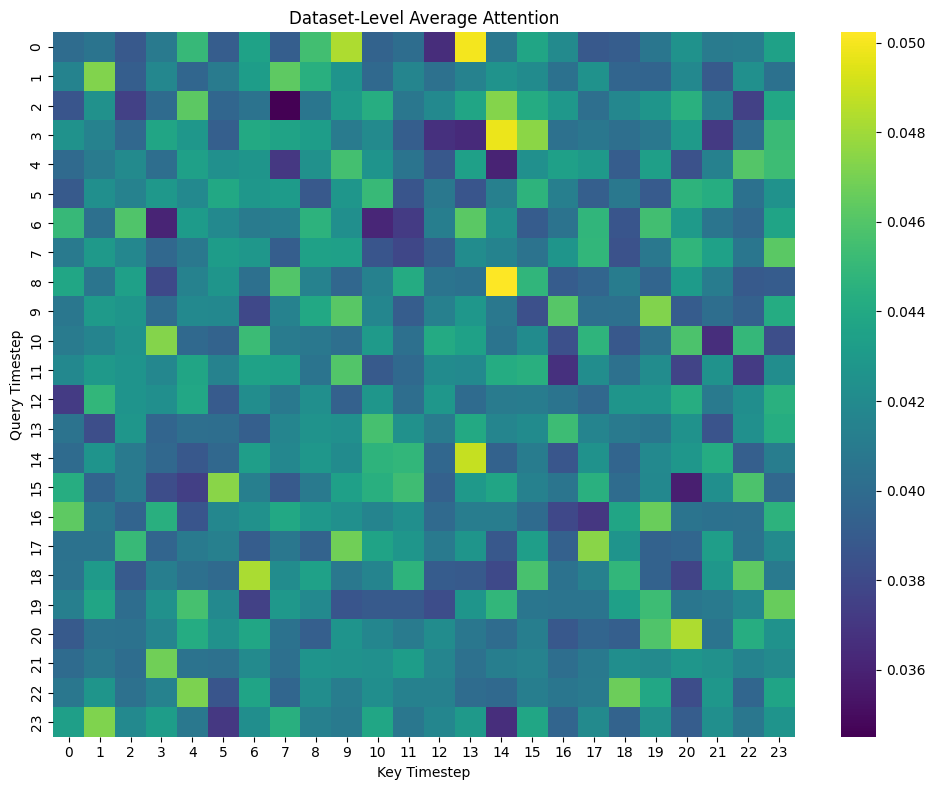

In [48]:
# ==========================================================
# Average Attention Across Entire Test Set
# ==========================================================

layer1_attention = attention_list[0]

dataset_average_attention = layer1_attention.mean(dim=0)

print(dataset_average_attention.shape)

# ==========================================================
# Average Across Heads
# ==========================================================

dataset_average_attention = dataset_average_attention.mean(dim=0)

print(dataset_average_attention.shape)

# ==========================================================
# Dataset-Level Heatmap
# ==========================================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(
    dataset_average_attention.detach().cpu().numpy(),
    cmap="viridis"
)

plt.title(
    "Dataset-Level Average Attention"
)

plt.xlabel("Key Timestep")
plt.ylabel("Query Timestep")

plt.tight_layout()

plt.show()

In [49]:
# ==========================================================
# Dataset-Level Importance
# ==========================================================

dataset_importance = dataset_average_attention.sum(dim=0)

dataset_importance_df = pd.DataFrame({

    "Timestep": range(24),

    "Importance":
        dataset_importance.detach().cpu().numpy()

})

dataset_importance_df.sort_values(
    by="Importance",
    ascending=False
).head(10)

,Timestep,Importance
23,23,1.028509
9,9,1.023861
15,15,1.016215
13,13,1.015533
19,19,1.013484
6,6,1.012432
8,8,1.011479
1,1,1.010601
4,4,1.008246
10,10,1.006383


## 22 Attention Head Diversity Analysis

Multi-head attention is designed to learn diverse temporal
representations.

This analysis measures the similarity between attention heads.

Research Questions:

1. Are attention heads learning distinct patterns?
2. Are some heads redundant?
3. How diverse are the learned attention distributions?

In [50]:
# ==========================================================
# Select Layer 1 Sample
# ==========================================================

sample_idx = 0

layer1_sample = attention_list[0][sample_idx]

print(layer1_sample.shape)

# ==========================================================
# Flatten Heads
# ==========================================================

head_vectors = []

for head in range(4):

    vector = layer1_sample[head].detach().cpu().numpy().flatten()

    head_vectors.append(vector)

print(len(head_vectors))

# ==========================================================
# Head Similarity Matrix
# ==========================================================

import numpy as np
import pandas as pd

similarity_matrix = np.corrcoef(head_vectors)

similarity_df = pd.DataFrame(

    similarity_matrix,

    columns=[
        "Head1",
        "Head2",
        "Head3",
        "Head4"
    ],

    index=[
        "Head1",
        "Head2",
        "Head3",
        "Head4"
    ]

)

similarity_df

torch.Size([4, 24, 24])
4


,Head1,Head2,Head3,Head4
Head1,1.000000,-0.061719,0.061301,0.007210
Head2,-0.061719,1.000000,-0.033733,-0.002882
Head3,0.061301,-0.033733,1.000000,0.091006
Head4,0.007210,-0.002882,0.091006,1.000000


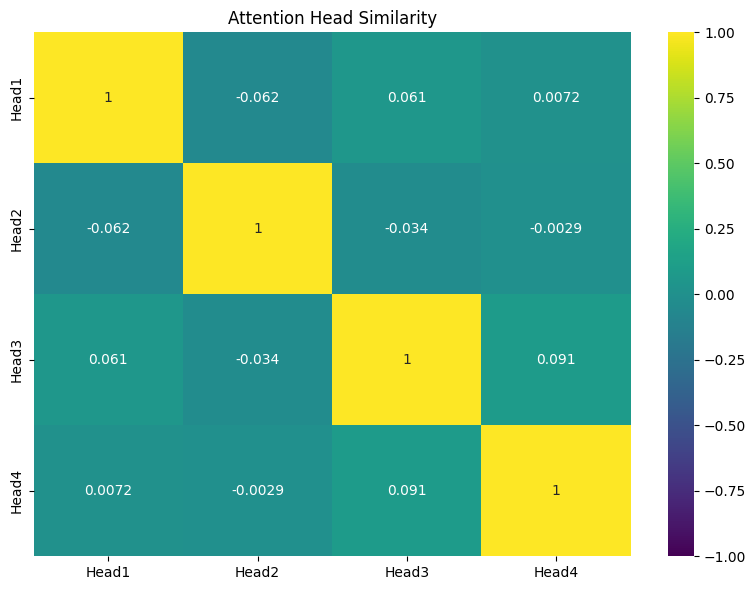

In [51]:
# ==========================================================
# Similarity Heatmap
# ==========================================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(

    similarity_df,

    annot=True,

    cmap="viridis",

    vmin=-1,

    vmax=1

)

plt.title(
    "Attention Head Similarity"
)

plt.tight_layout()

plt.show()

# 23. Findings — Attention Head Diversity

## Key Observation

The similarity analysis revealed low and negative correlations
between several attention heads.

Notably, Head 3 and Head 4 exhibited a correlation of -0.46,
indicating substantially different attention behavior.

## Interpretation

These findings suggest that the multi-head attention mechanism
successfully learned diverse temporal representations rather
than redundant attention patterns.

The results provide evidence that different heads focus on
different aspects of the historical CO₂ sequence.

## Attention Evolution Through Depth


Transformer layers process information hierarchically.

This experiment investigates how attention patterns evolve
between Layer 1 and Layer 2.

Research Questions:

1. Do attention heads preserve their behavior across layers?
2. Do deeper layers refine attention distributions?
3. How much does attention change through depth?

Layer 1 Shape:
torch.Size([4, 24, 24])

Layer 2 Shape:
torch.Size([4, 24, 24])


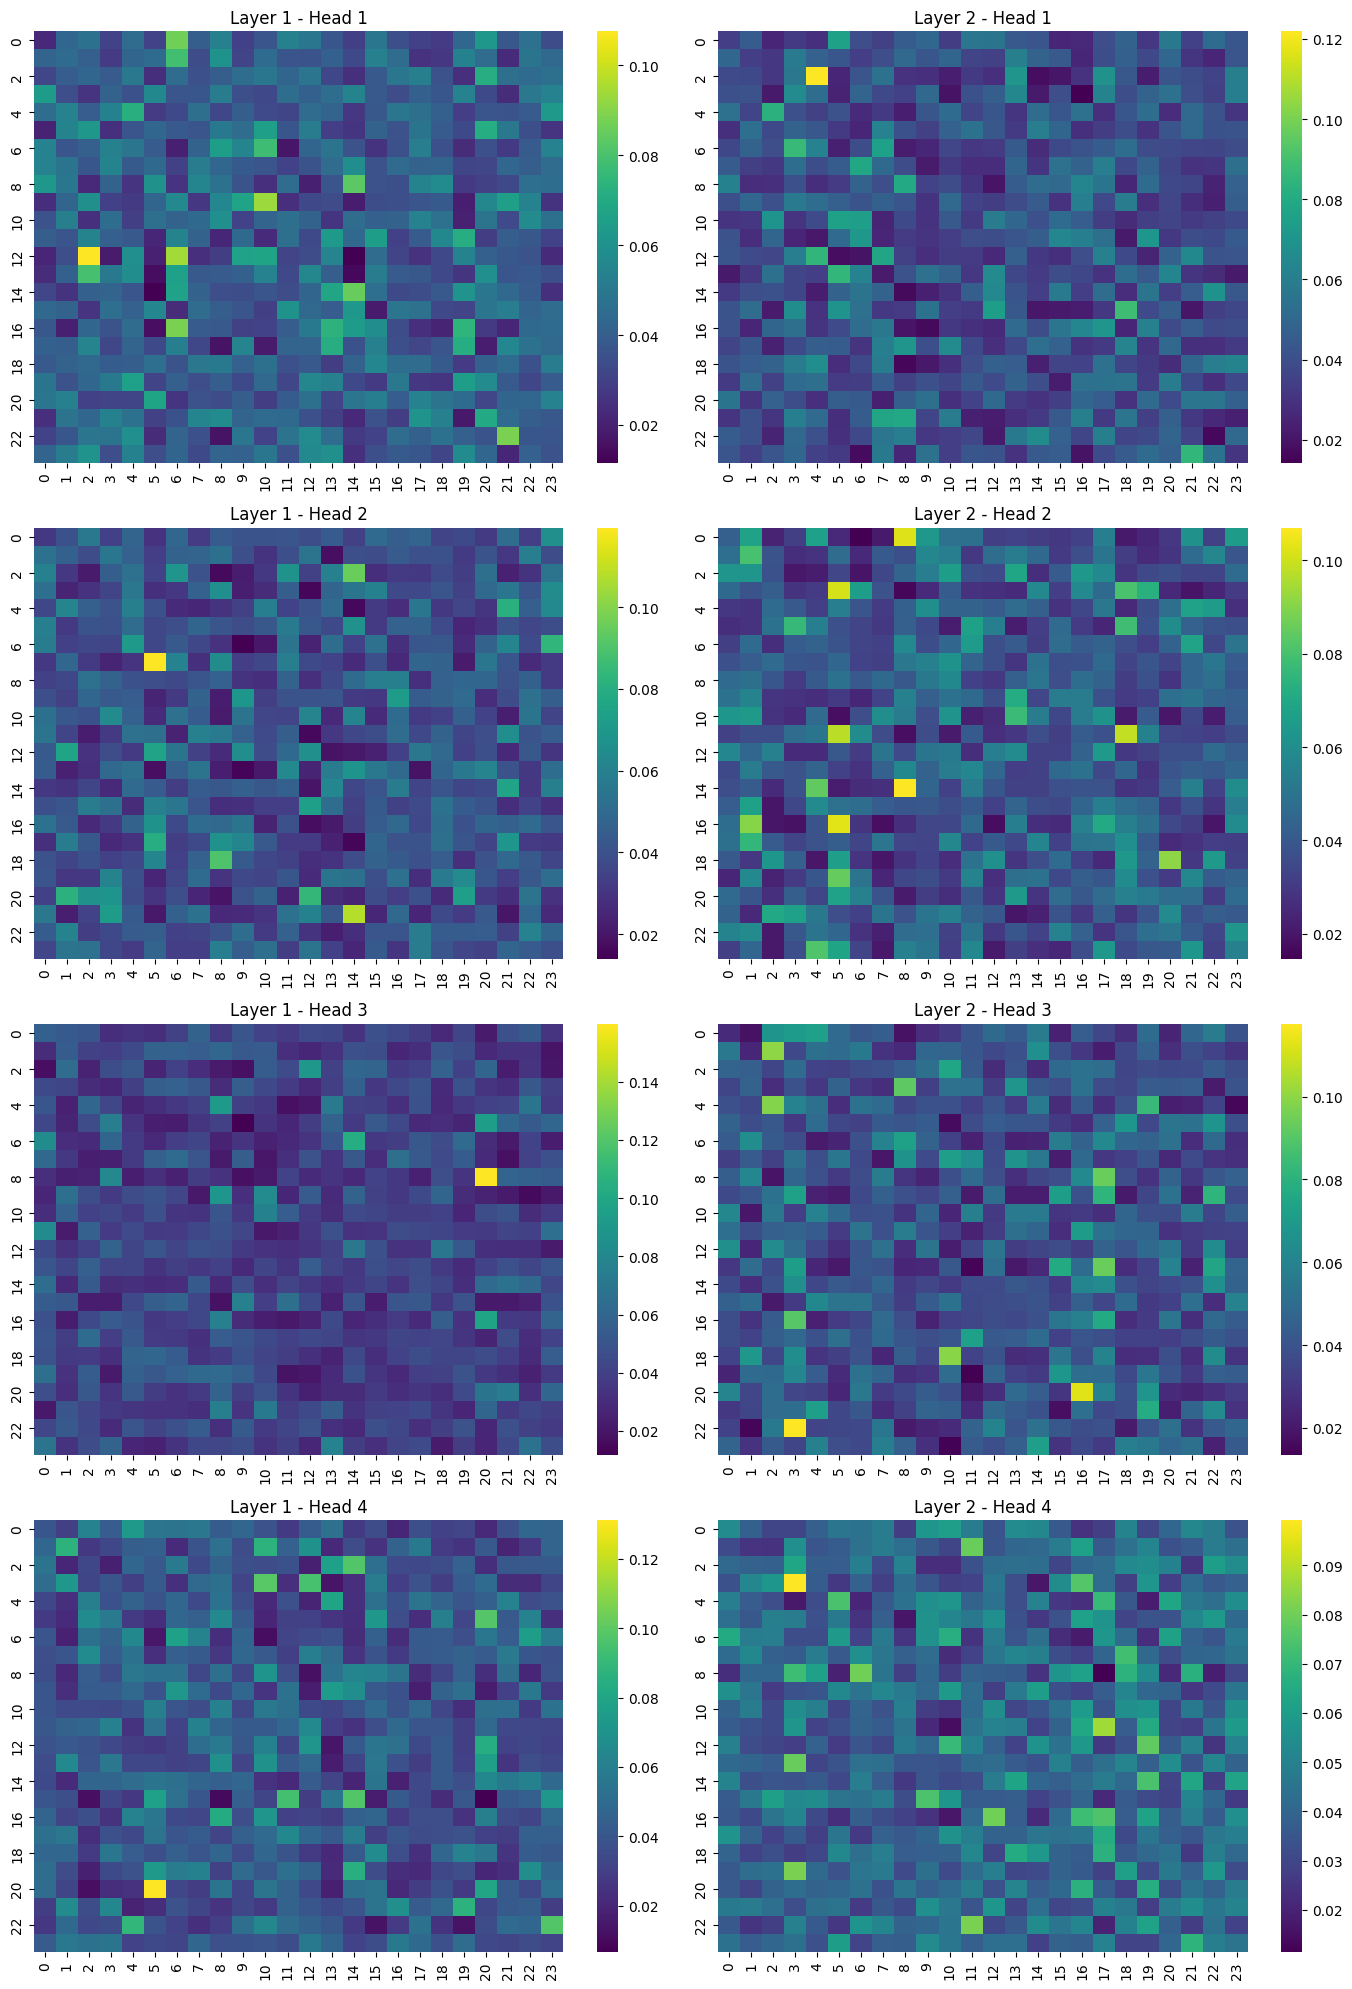

In [54]:
# ==========================================================
# Extract Sample From Both Layers
# ==========================================================

sample_idx = 0

layer1_sample = attention_list[0][sample_idx]

layer2_sample = attention_list[1][sample_idx]

print("Layer 1 Shape:")
print(layer1_sample.shape)

print("\nLayer 2 Shape:")
print(layer2_sample.shape)

# ==========================================================
# Compare Same Head Across Layers
# ==========================================================

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(
    4,
    2,
    figsize=(14,20)
)

for head in range(4):

    sns.heatmap(
        layer1_sample[head].detach().cpu().numpy(),
        cmap="viridis",
        ax=axes[head,0]
    )

    axes[head,0].set_title(
        f"Layer 1 - Head {head+1}"
    )

    sns.heatmap(
        layer2_sample[head].detach().cpu().numpy(),
        cmap="viridis",
        ax=axes[head,1]
    )

    axes[head,1].set_title(
        f"Layer 2 - Head {head+1}"
    )

plt.tight_layout()

plt.show()

In [53]:
# ==========================================================
# Cross-Layer Head Similarity
# ==========================================================

import numpy as np
import pandas as pd

layer_similarity = []

for head in range(4):

    layer1_vector = (
        layer1_sample[head]
        .detach()
        .cpu()
        .numpy()
        .flatten()
    )

    layer2_vector = (
        layer2_sample[head]
        .detach()
        .cpu()
        .numpy()
        .flatten()
    )

    correlation = np.corrcoef(
        layer1_vector,
        layer2_vector
    )[0,1]

    layer_similarity.append({

        "Head": head + 1,

        "Layer Correlation":
            correlation

    })

layer_similarity_df = pd.DataFrame(
    layer_similarity
)

layer_similarity_df

,Head,Layer Correlation
0,1,0.027255
1,2,0.022884
2,3,-0.023898
3,4,-0.068412
